## Import thư viện

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load dữ liệu

In [ ]:
df = pd.read_csv("country_vaccinations_transformed.csv")
df.head(10)

,country,iso_code,date,total_vaccinations,people_vaccinated,people_fully_vaccinated,daily_vaccinations_raw,daily_vaccinations,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,daily_vaccinations_per_million,vaccines,source_name,source_website,vaccine_count,dropout_date,coverage_group,daily_vaccination_7d_avg,vaccination_momentum
0,Afghanistan,AFG,2021-05-27,593313.0,479574.0,113739.0,2859.0,6487.0,1.52,1.23,0.29,167.0,"BBIBP-CorV, Oxford/AstraZeneca, Pfizer/BioNTech",World Health Organization,https://covid19.who.int/,3,76.283326,Low,6487.000000,1.093352
1,Afghanistan,AFG,2021-06-03,630305.0,481800.0,148505.0,4015.0,5285.0,1.62,1.24,0.38,136.0,"BBIBP-CorV, Oxford/AstraZeneca, Pfizer/BioNTech",World Health Organization,https://covid19.who.int/,3,69.177044,Low,5886.000000,0.838483
2,Albania,ALB,2021-02-18,3049.0,2438.0,611.0,1348.0,254.0,0.11,0.08,0.02,88.0,"Oxford/AstraZeneca, Pfizer/BioNTech, Sinovac, ...",Ministry of Health,https://shendetesia.gov.al/vaksinimi-anticovid...,4,74.938474,Low,254.000000,8.330600
3,Albania,ALB,2021-05-11,622507.0,440921.0,181586.0,9548.0,12160.0,21.63,15.32,6.31,4225.0,"Oxford/AstraZeneca, Pfizer/BioNTech, Sinovac, ...",Ministry of Health,https://shendetesia.gov.al/vaksinimi-anticovid...,4,58.816659,Low,6207.000000,1.953392
4,Albania,ALB,2021-05-12,632676.0,444755.0,187921.0,10169.0,10870.0,21.98,15.45,6.53,3777.0,"Oxford/AstraZeneca, Pfizer/BioNTech, Sinovac, ...",Ministry of Health,https://shendetesia.gov.al/vaksinimi-anticovid...,4,57.747299,Low,7761.333333,1.718099
5,Albania,ALB,2021-05-13,638338.0,445402.0,192936.0,5662.0,9445.0,22.18,15.48,6.70,3282.0,"Oxford/AstraZeneca, Pfizer/BioNTech, Sinovac, ...",Ministry of Health,https://shendetesia.gov.al/vaksinimi-anticovid...,4,56.682727,Low,8182.250000,1.479624
6,Albania,ALB,2021-05-14,653330.0,448571.0,204759.0,14992.0,9662.0,22.70,15.59,7.12,3357.0,"Oxford/AstraZeneca, Pfizer/BioNTech, Sinovac, ...",Ministry of Health,https://shendetesia.gov.al/vaksinimi-anticovid...,4,54.353046,Low,8478.200000,1.478885
7,Albania,ALB,2021-05-18,688947.0,460191.0,228756.0,8864.0,9491.0,23.94,15.99,7.95,3298.0,"Oxford/AstraZeneca, Pfizer/BioNTech, Sinovac, ...",Ministry of Health,https://shendetesia.gov.al/vaksinimi-anticovid...,4,50.291075,Low,8647.000000,1.377610
8,Albania,ALB,2021-05-19,697811.0,463402.0,234409.0,8864.0,9305.0,24.25,16.10,8.15,3233.0,"Oxford/AstraZeneca, Pfizer/BioNTech, Sinovac, ...",Ministry of Health,https://shendetesia.gov.al/vaksinimi-anticovid...,4,49.415626,Low,8741.000000,1.333456
9,Albania,ALB,2021-05-20,703743.0,466083.0,237660.0,5932.0,9344.0,24.45,16.20,8.26,3247.0,"Oxford/AstraZeneca, Pfizer/BioNTech, Sinovac, ...",Ministry of Health,https://shendetesia.gov.al/vaksinimi-anticovid...,4,49.009082,Low,10039.571429,1.327757


## Các biểu đồ tổng quan

Gom các biến chính cần được chú ý đến

In [ ]:
num_cols = [
    "total_vaccinations_per_hundred",
    "people_vaccinated_per_hundred",
    "people_fully_vaccinated_per_hundred",
    "daily_vaccinations_per_million",
    "dropout_date",
    "vaccination_momentum"
]

1. Tương quan giữa các biến chính

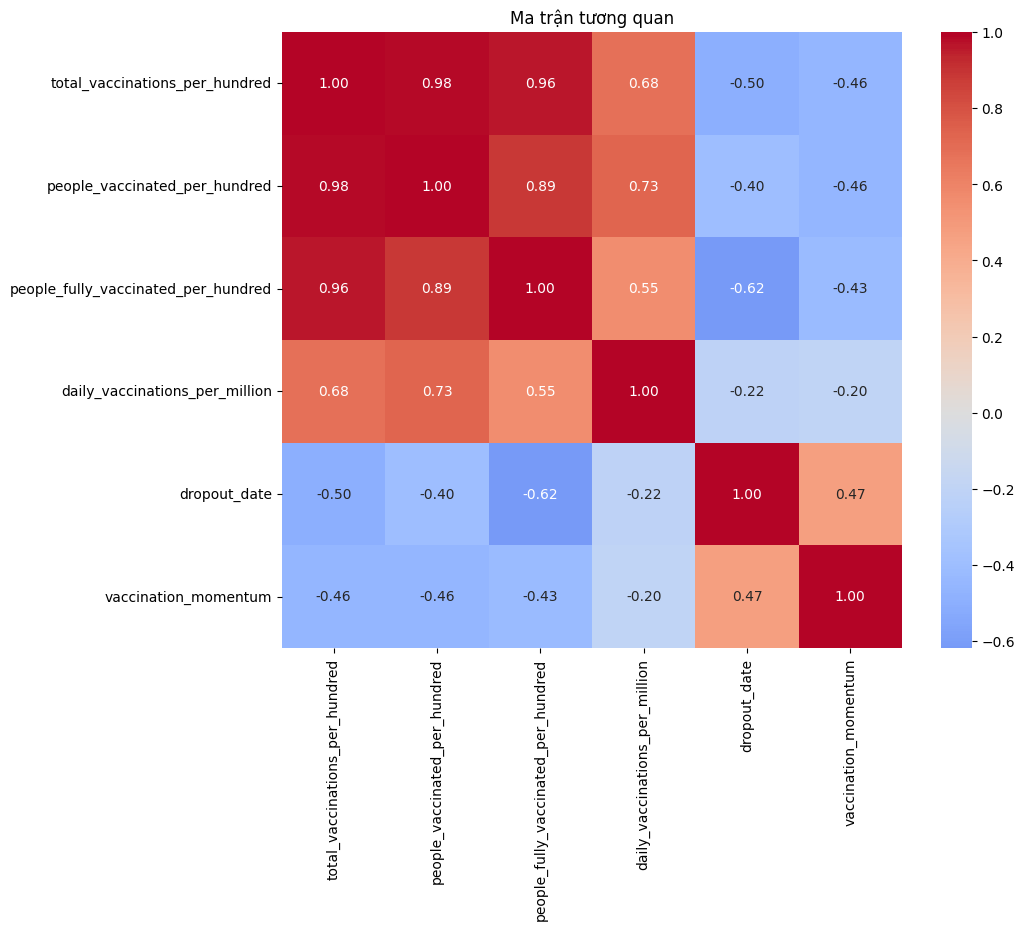

In [ ]:
corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Ma trận tương quan")
plt.show()

2. Thống kê outliers của các biến chính

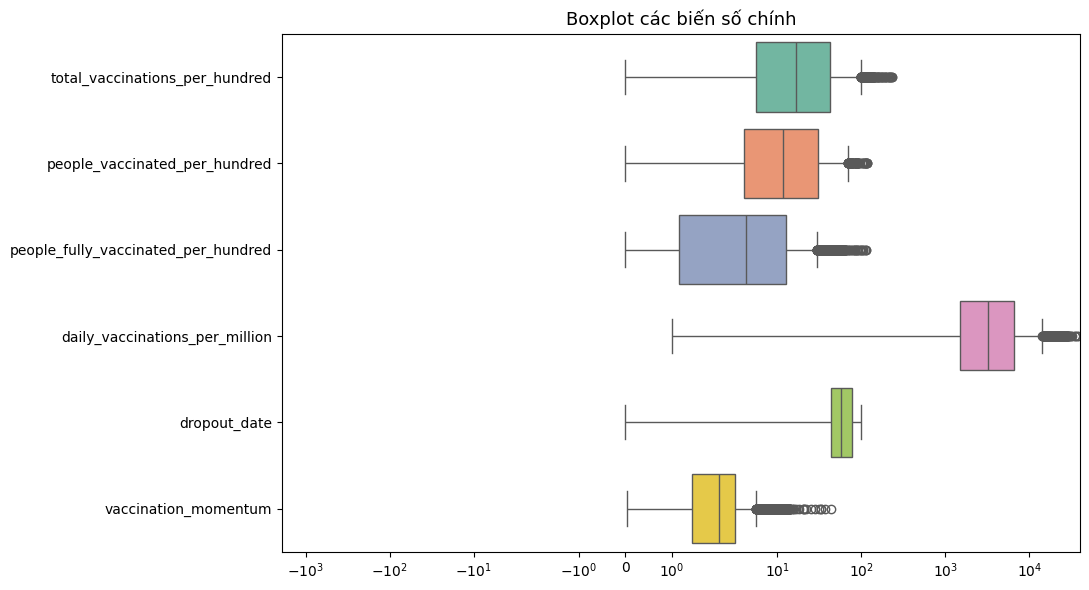

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(data=df[num_cols], orient="h", palette="Set2", ax=ax)
ax.set_title("Boxplot các biến số chính", fontsize=13)
ax.set_xscale("symlog")
plt.tight_layout()
plt.show()

3. Phân bố các nhóm bao phủ vaccine

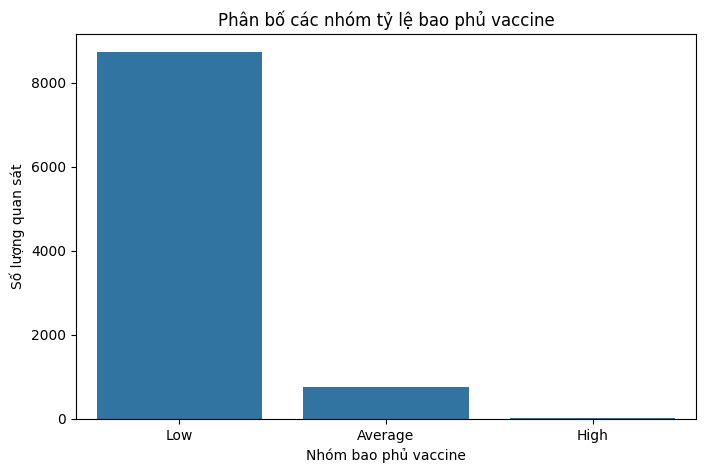

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="coverage_group"
)

plt.title("Phân bố các nhóm tỷ lệ bao phủ vaccine")
plt.xlabel("Nhóm bao phủ vaccine")
plt.ylabel("Số lượng quan sát")
plt.show()

4. Phân phối tỉ lệ dân số tiêm đầy đủ

Xem tỷ lệ bao phủ vaccine đầy đủ của các quốc gia/quan sát phân bố như thế nào.

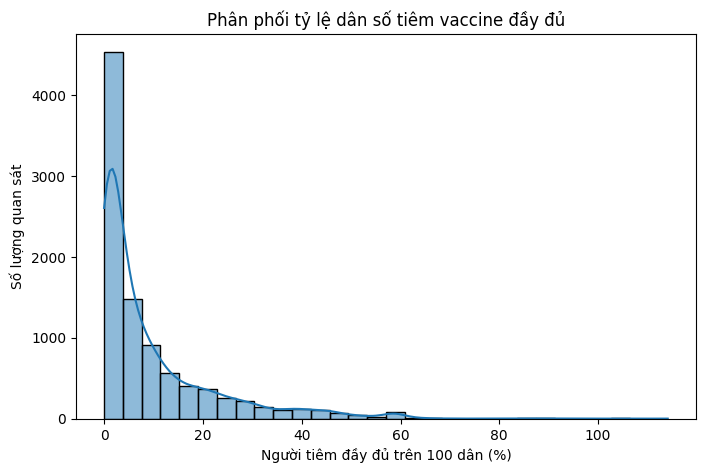

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="people_fully_vaccinated_per_hundred",
    bins=30,
    kde=True
)

plt.title("Phân phối tỷ lệ dân số tiêm vaccine đầy đủ")
plt.xlabel("Người tiêm đầy đủ trên 100 dân (%)")
plt.ylabel("Số lượng quan sát")
plt.show()

5. Top 10 quốc gia có số bản ghi cao nhất

/tmp/ipykernel_1699/2223111146.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.values, y=top10.index, palette="rocket", ax=ax)


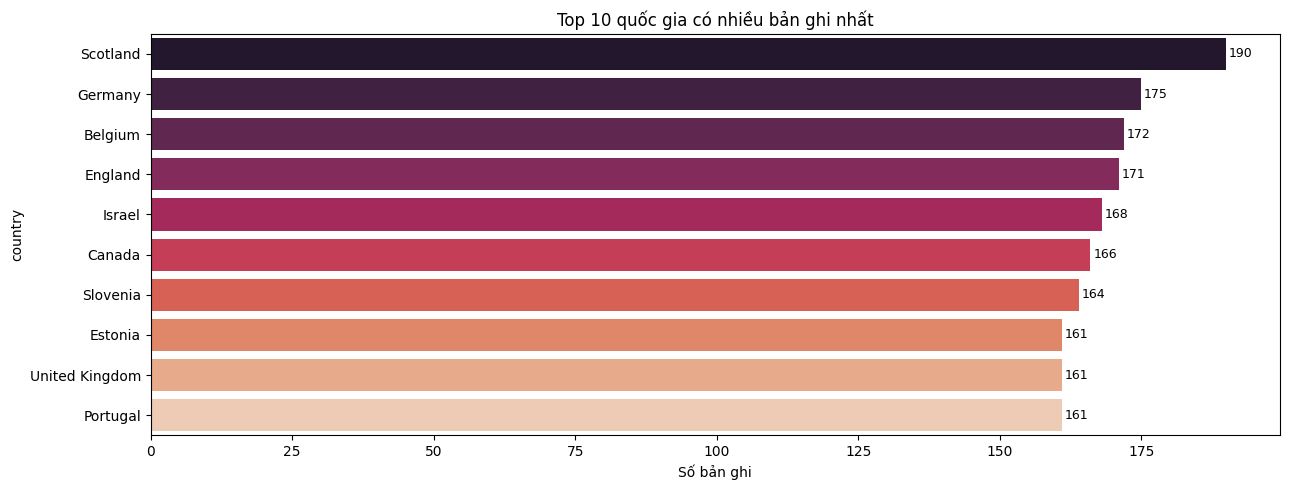

In [ ]:
fig, ax = plt.subplots(figsize=(13, 5))

top10 = df["country"].value_counts().head(10)
sns.barplot(x=top10.values, y=top10.index, palette="rocket", ax=ax)
ax.set_title("Top 10 quốc gia có nhiều bản ghi nhất")
ax.set_xlabel("Số bản ghi")
for i, v in enumerate(top10.values):
    ax.text(v + 0.5, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.show()